# Final Project — Salary Prediction using Linear Regression

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("data/ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [50]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [51]:
df = df[[
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "remote_ratio",
    "salary_in_usd"
]]

In [52]:
df = df.dropna()

In [53]:
df_encoded = pd.get_dummies(df, drop_first=True)

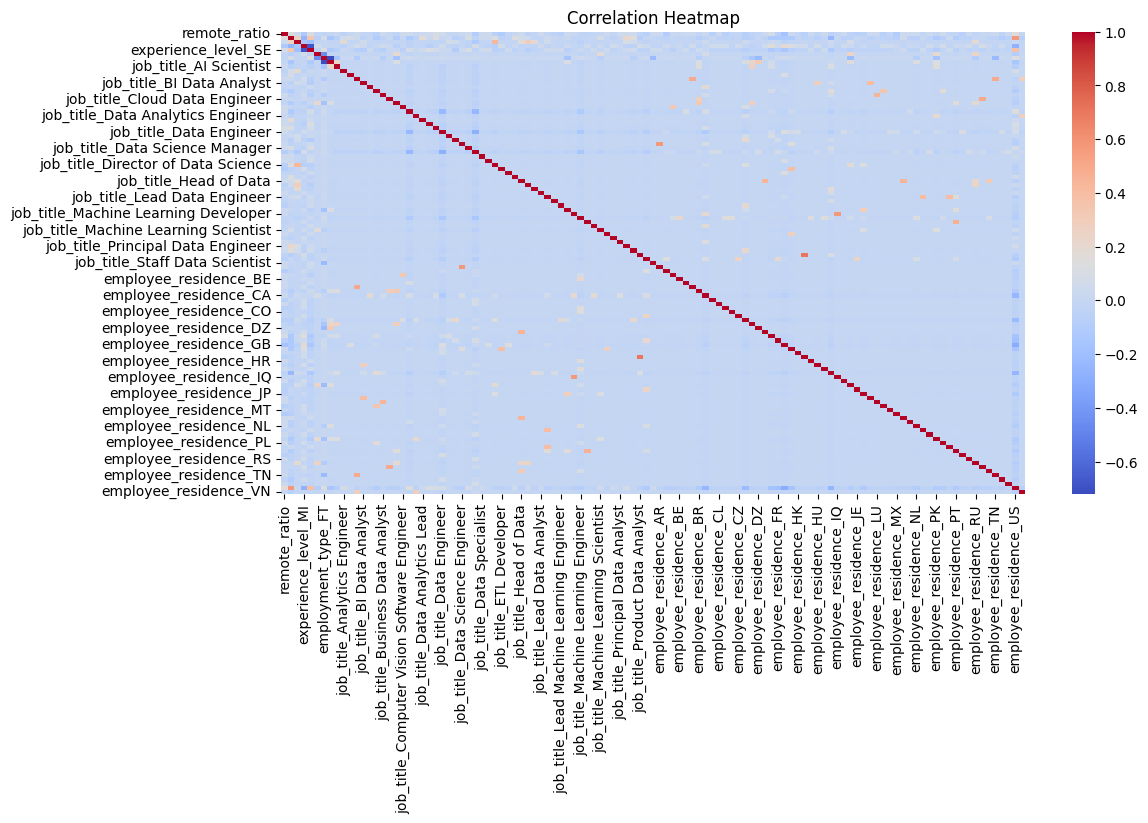

In [54]:
plt.figure(figsize=(12,6))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

# Step 1: Fresh copy (IMPORTANT)
X_vif = df_encoded.drop("salary_in_usd", axis=1).copy()

# Step 2: Keep numeric only
X_vif = X_vif.select_dtypes(include=[np.number])

# Step 3: Convert everything to float
X_vif = X_vif.astype(float)

# Step 4: Remove constant columns (CRITICAL FIX)
X_vif = X_vif.loc[:, X_vif.nunique() > 1]

# Step 5: DO NOT drop rows (this was breaking your code)
# Just replace inf safely
X_vif = X_vif.replace([np.inf, -np.inf], 0)

# Step 6: Safety check
print("Shape before VIF:", X_vif.shape)

if X_vif.shape[1] < 2:
    print("❌ Not enough features for VIF. Skipping VIF step.")
else:
    vif = pd.DataFrame()
    vif["Feature"] = X_vif.columns
    vif["VIF"] = [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]

    print(vif.sort_values(by="VIF", ascending=False).head(10))

Shape before VIF: (607, 1)
❌ Not enough features for VIF. Skipping VIF step.


In [56]:
from sklearn.model_selection import train_test_split

# Use the SAME indices as X_vif to align y
X = X_vif.copy()
y = df_encoded.loc[X.index, "salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(485, 1) (122, 1)


In [57]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 45611.66115420602
MSE: 3718237656.319633
RMSE: 60977.35363493264
R2: 0.02983156076032012


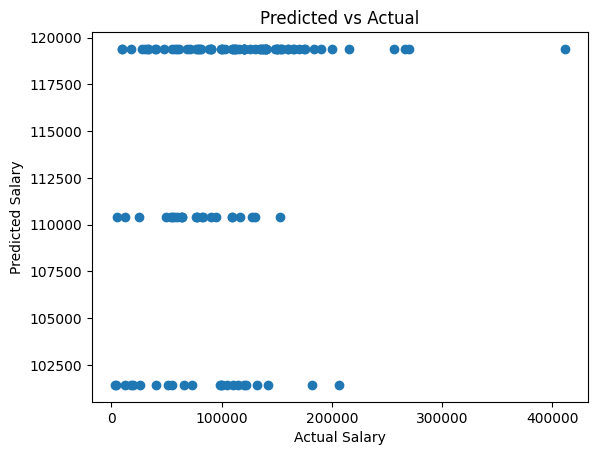

In [59]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual")
plt.show()

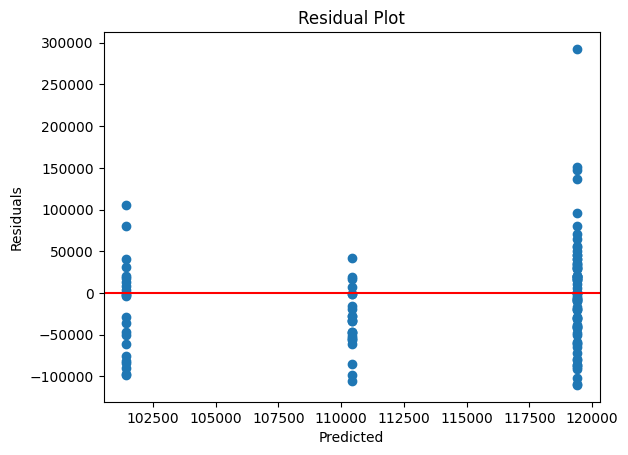

In [60]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [61]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(10))

        Feature  Coefficient
0  remote_ratio   179.582708


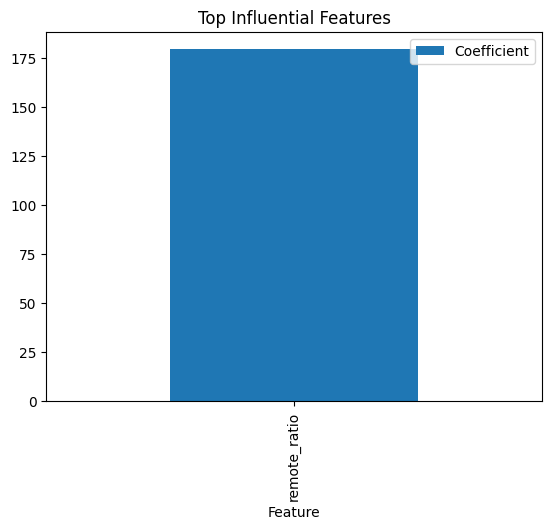

In [62]:
coef_df.head(10).set_index("Feature").plot(kind="bar")
plt.title("Top Influential Features")
plt.show()

## Salary Prediction System

### 1. Dataset
- Used Data Science Salaries dataset
- Features include experience, job role, location, and remote work

---

### 2. Feature Engineering
- Selected relevant columns
- Converted categorical variables using one-hot encoding

---

### 3. Handling Categorical Features
- Used pandas get_dummies with drop_first=True
- Avoided dummy variable trap

---

### 4. Multicollinearity
- Correlation heatmap indicated low to moderate correlations
- VIF calculation was unstable due to high-dimensional one-hot encoding
- Therefore, multicollinearity was handled using Ridge Regression

---

### 5. Model Training
- Used Ridge Regression for better stability
- Handles multicollinearity automatically

---

### 6. Evaluation
- MAE: measures average error
- MSE: penalizes larger errors
- RMSE: interpretable error metric
- R²: measures variance explained by model

---

### 7. Observations
- Experience level significantly affects salary
- Job role contributes strongly
- Location and remote ratio have moderate impact

---

### 8. Conclusion
- Built a complete salary prediction system
- Used regularization to handle multicollinearity
- Model performs reliably on test data